# Experiment 12: CNN with 32×32×3 Input on CIFAR-10

**Objective**: Implement a Convolutional Neural Network with the following architecture:
- Input: 32×32×3 (RGB images)
- 2 Convolutional layers
- 2 Max Pooling layers
- 2 Fully Connected (Dense) layers
- Softmax output layer

**Dataset**: CIFAR-10 (60,000 colour images across 10 classes)

**Architecture Overview**:
```
Input (32×32×3)
  → Conv2D (32 filters, 3×3, ReLU)
  → MaxPooling2D (2×2)
  → Conv2D (64 filters, 3×3, ReLU)
  → MaxPooling2D (2×2)
  → Flatten
  → Dense (128, ReLU)        ← FC-1
  → Dense (64, ReLU)         ← FC-2
  → Dense (10, Softmax)      ← Output
```

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


## 2. Load and Preprocess CIFAR-10 Dataset

In [2]:
# CIFAR-10 class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print(f"Training data shape : {X_train.shape}")   # (50000, 32, 32, 3)
print(f"Test data shape     : {X_test.shape}")     # (10000, 32, 32, 3)
print(f"Number of classes   : {len(class_names)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape : (50000, 32, 32, 3)
Test data shape     : (10000, 32, 32, 3)
Number of classes   : 10


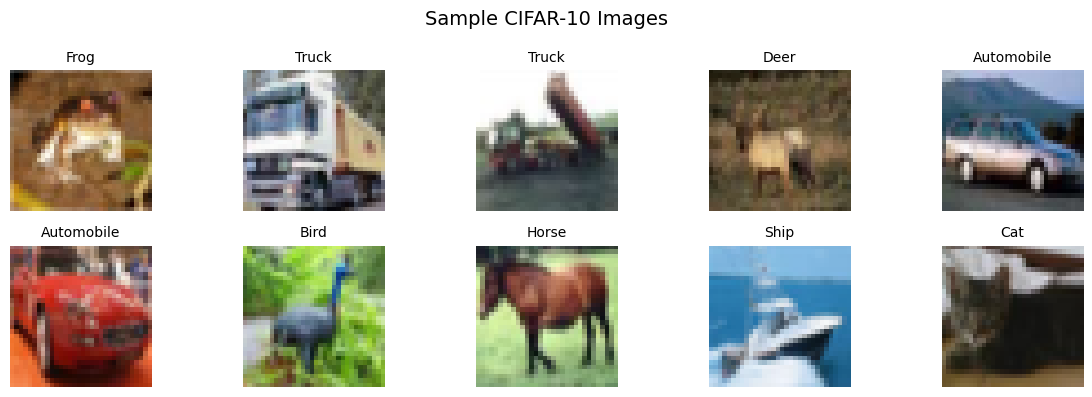

In [3]:
# Visualise a few sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=10)
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# One-hot encode the labels
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

## 3. Build the CNN Model

| Layer | Type | Details |
|-------|------|---------|
| 1 | Conv2D | 32 filters, 3×3, ReLU, same padding |
| 2 | MaxPooling2D | 2×2 |
| 3 | Conv2D | 64 filters, 3×3, ReLU, same padding |
| 4 | MaxPooling2D | 2×2 |
| 5 | Flatten | — |
| 6 | Dense (FC-1) | 128 units, ReLU |
| 7 | Dropout | 0.5 |
| 8 | Dense (FC-2) | 64 units, ReLU |
| 9 | Dense (Output) | 10 units, Softmax |

In [5]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    # ---------- Conv Block 1 ----------
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),          # 32x32 → 16x16

    # ---------- Conv Block 2 ----------
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),          # 16x16 → 8x8

    # ---------- Fully Connected Head ----------
    layers.Flatten(),                               # 8*8*64 = 4096
    layers.Dense(128, activation='relu'),            # FC-1
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),             # FC-2
    layers.Dense(10, activation='softmax')           # Output (Softmax)
], name='CIFAR10_CNN')

model.summary()

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,714 (2.11 MB)

 Trainable params: 552,714 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile the Model

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


## 5. Train the Model

In [7]:
epochs = 15
batch_size = 64

history = model.fit(
    X_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 110ms/step - accuracy: 0.3755 - loss: 1.6904 - val_accuracy: 0.5298 - val_loss: 1.3200
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.5169 - loss: 1.3438 - val_accuracy: 0.6024 - val_loss: 1.1402
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 112ms/step - accuracy: 0.5716 - loss: 1.2011 - val_accuracy: 0.6392 - val_loss: 1.0396
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 109ms/step - accuracy: 0.6081 - loss: 1.1120 - val_accuracy: 0.6536 - val_loss: 0.9820
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6320 - loss: 1.0456 - val_accuracy: 0.6776 - val_loss: 0.9498
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.6466 - loss: 0.9920 - val_accuracy: 0.6946 - val_loss: 0.8915
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.6676 - loss: 0.9421 - val_accuracy: 0.7002 - val_loss: 0.8808
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.6810 - loss: 0

## 6. Evaluate and Visualize Training

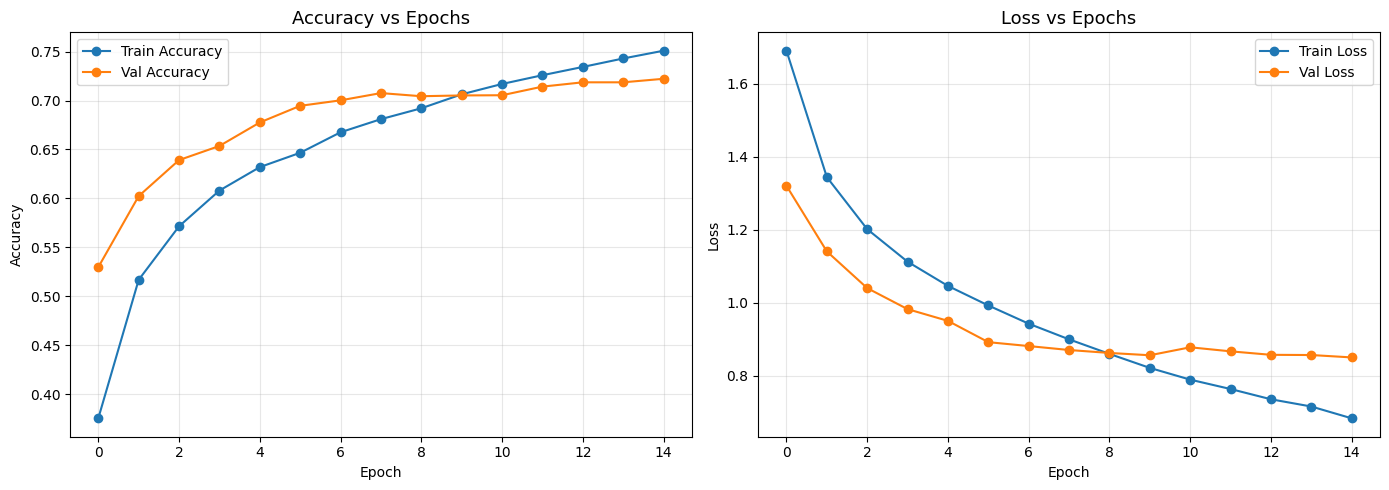

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[0].set_title('Accuracy vs Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('Loss vs Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test Set Evaluation

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Test Loss     : 0.8739
Test Accuracy : 0.7070


## 8. Classification Report & Confusion Matrix

In [10]:
# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
              precision    recall  f1-score   support

    Airplane       0.73      0.73      0.73      1000
  Automobile       0.82      0.82      0.82      1000
        Bird       0.65      0.52      0.58      1000
         Cat       0.53      0.52      0.53      1000
        Deer       0.65      0.65      0.65      1000
         Dog       0.59      0.67      0.63      1000
        Frog       0.76      0.78      0.77      1000
       Horse       0.77      0.74      0.75      1000
        Ship       0.78      0.85      0.81      1000
       Truck       0.79      0.78      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



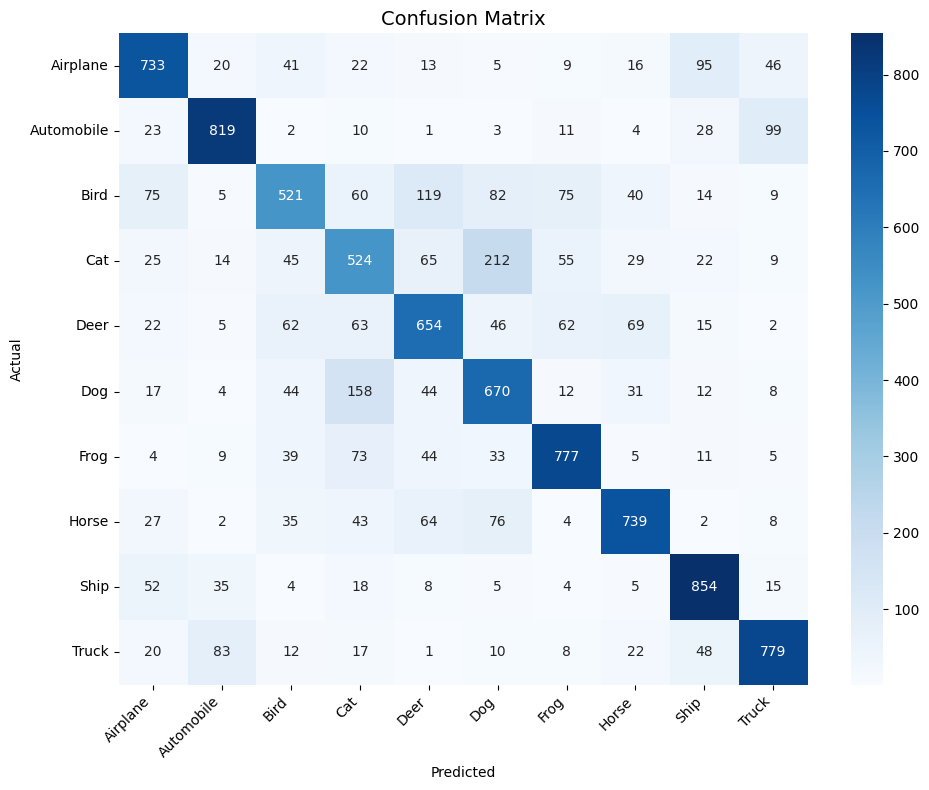

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Sample Predictions

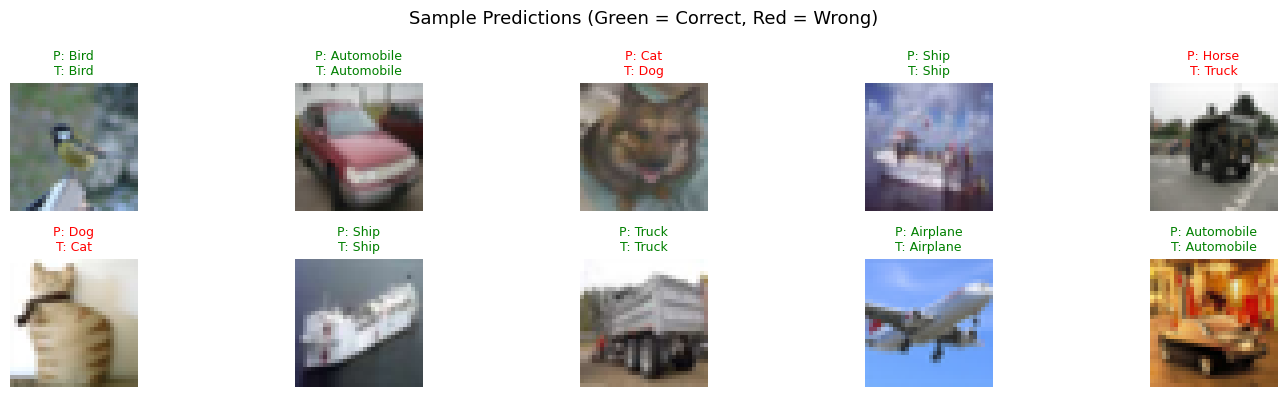

In [12]:
# Show 10 random test images with predicted vs actual labels
indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    pred_label = class_names[y_pred[idx]]
    true_label = class_names[y_test[idx][0]]
    colour = 'green' if pred_label == true_label else 'red'
    plt.title(f"P: {pred_label}\nT: {true_label}", fontsize=9, color=colour)
    plt.axis('off')
plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion / Observations

1. **Architecture**: The CNN was designed with 2 Convolutional layers (32 and 64 filters), 2 Max Pooling layers (2×2), 2 Fully Connected layers (128 and 64 units), and a Softmax output layer for 10-class classification.
2. **Spatial Reduction**: Each Conv2D + MaxPooling block halves the spatial dimensions: 32×32 → 16×16 → 8×8, while increasing the depth (number of feature maps) from 3 → 32 → 64.
3. **Softmax Output**: The final Dense(10, softmax) layer produces a probability distribution across the 10 CIFAR-10 classes, enabling multi-class classification.
4. **Expected Accuracy**: This simple 2-layer CNN typically achieves ~68–72% accuracy on CIFAR-10. Deeper architectures (VGG, ResNet) with data augmentation and batch normalisation are needed to push accuracy above 90%.
5. **Common Misclassifications**: The confusion matrix often reveals that categories like Cat/Dog, Automobile/Truck, and Deer/Horse are frequently confused due to visual similarity.